# 02 — Exploratory Data Analysis

**Wind Turbine Predictive Maintenance & Failure Intelligence System**

## Objective
Explore the Wind Farm A sensor data to understand what normal operation looks
like and — most importantly — whether sensor behaviour changes measurably in the
run-up to a fault. This is the visual evidence that a predictive signal exists.

## What this notebook answers
- What do the key sensor distributions look like (temps, wind, power, RPM)?
- How do sensors relate to each other and to power output?
- Where are the fault windows in each anomaly run (via `event_start_id`/`event_end_id`)?
- **Does sensor behaviour (bearing / gearbox / generator / transformer temps)
  drift approaching the fault window vs during normal operation?**

## Recap from NB01 (the ground rules)
- The label is **not** `status_type_id` (that's an operating code). The fault
  window comes from `event_info.csv` via `event_start_id`/`event_end_id` on `id`.
- Use `_avg` sensor signals; `_min`/`_max`/`_std` are less reliable.
- Only ~12 fault events → treat findings as indicative, not statistically heavy.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

BASE = Path("..") / "data" / "raw" / "Wind Farm A"
DATASETS_DIR = BASE / "datasets"

# Event ground truth and feature descriptions (from NB01)
events = pd.read_csv(BASE / "event_info.csv", sep=";")
feat_desc = pd.read_csv(BASE / "feature_description.csv", sep=";")

# Map sensor_name -> human description, for readable plots
desc_map = dict(zip(feat_desc["sensor_name"], feat_desc["description"]))

def load_dataset(event_id):
    """Load one dataset CSV by its event id."""
    df = pd.read_csv(DATASETS_DIR / f"{event_id}.csv", sep=";")
    df["time_stamp"] = pd.to_datetime(df["time_stamp"])
    return df

print("Events:", events.shape, "| Features described:", feat_desc.shape)
print("Anomaly / normal:", dict(events["event_label"].value_counts()))

Events: (22, 8) | Features described: (54, 6)
Anomaly / normal: {'anomaly': 12, 'normal': 10}


## 1. Sensor distributions

Before comparing normal vs pre-fault behaviour, establish what the key sensors
look like overall. We focus on the physically meaningful `_avg` signals across a
representative sample of turbines, grouped by type: environmental, temperatures,
power/electrical, and rotational.

In [2]:
# Pool a few NORMAL runs to characterise typical operation (avoids fault-window skew)
normal_ids = events.loc[events["event_label"] == "normal", "event_id"].tolist()
sample_ids = normal_ids[:4]   # 4 normal runs is plenty for distributions
print("Sampling normal runs:", sample_ids)

frames = []
for eid in sample_ids:
    d = load_dataset(eid)
    frames.append(d)
pool = pd.concat(frames, ignore_index=True)
print("Pooled rows:", len(pool))

# Keep only status 0 (normal operating state) for a clean "typical" picture
pool_norm = pool[pool["status_type_id"] == 0]
print("Rows in status 0 (normal operating):", len(pool_norm))

Sampling normal runs: [25, 69, 13, 24]
Pooled rows: 218538
Rows in status 0 (normal operating): 197691


Missing (should be empty): []


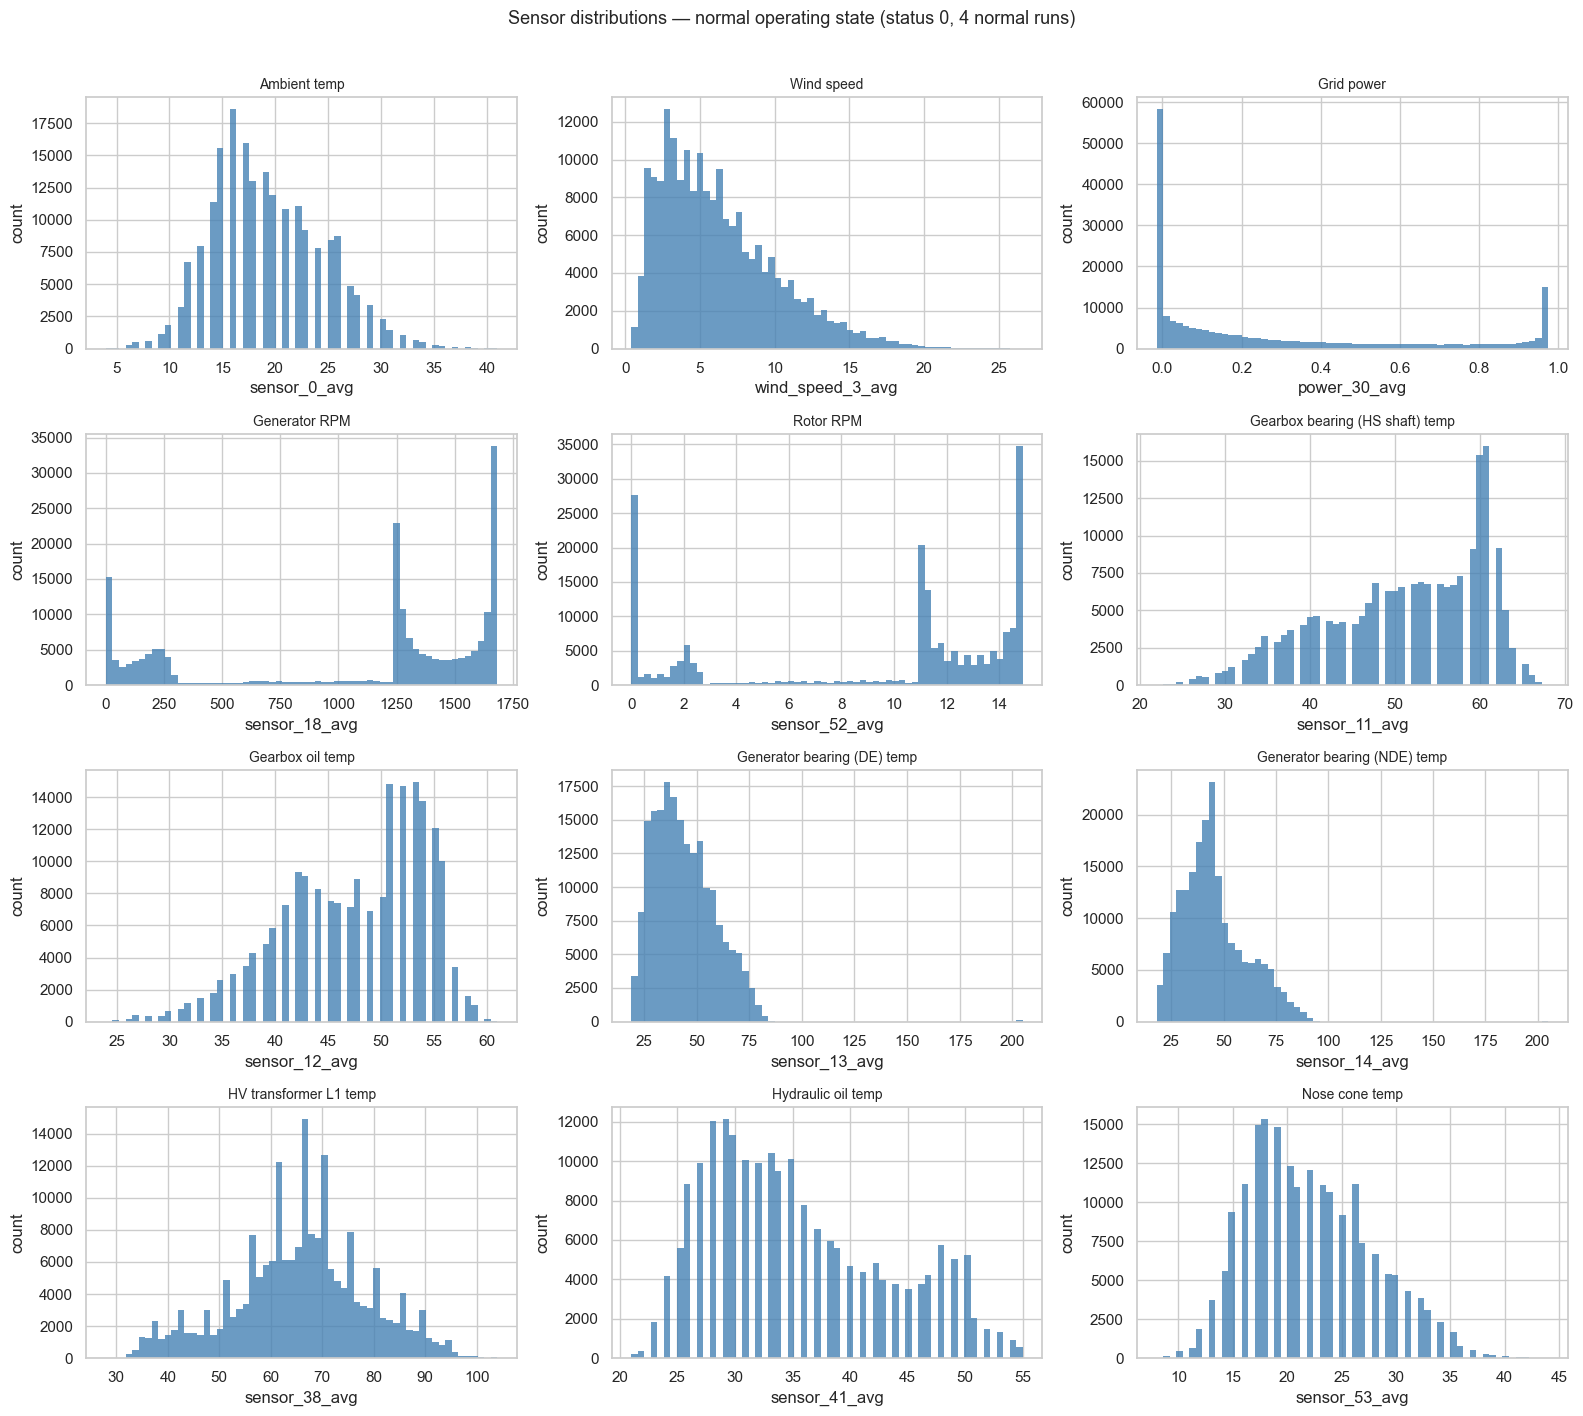

In [3]:
# Key sensors for this project, by their real meaning (from feature_description)
key_sensors = {
    "sensor_0_avg":  "Ambient temp",
    "wind_speed_3_avg": "Wind speed",
    "power_30_avg":  "Grid power",
    "sensor_18_avg": "Generator RPM",
    "sensor_52_avg": "Rotor RPM",
    "sensor_11_avg": "Gearbox bearing (HS shaft) temp",
    "sensor_12_avg": "Gearbox oil temp",
    "sensor_13_avg": "Generator bearing (DE) temp",
    "sensor_14_avg": "Generator bearing (NDE) temp",
    "sensor_38_avg": "HV transformer L1 temp",
    "sensor_41_avg": "Hydraulic oil temp",
    "sensor_53_avg": "Nose cone temp",
}

# Confirm they all exist in the data
missing = [c for c in key_sensors if c not in pool_norm.columns]
print("Missing (should be empty):", missing)

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, (col, label) in zip(axes.flat, key_sensors.items()):
    data = pool_norm[col].dropna()
    ax.hist(data, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(f"{col}")
    ax.set_ylabel("count")

plt.suptitle("Sensor distributions — normal operating state (status 0, 4 normal runs)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/02_sensor_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### Distribution findings

- **Power & RPM are bimodal** (idle vs rated) — turbines are either stopped or
  running near capacity, with a sparse middle. Implication: operating state is a
  strong confound; later models/features must account for "is it running" so the
  signal isn't just on/off.
- **Wind speed** follows the expected right-skewed (Weibull-like) shape — healthy.
- **Generator bearing temps (DE & NDE)** sit ~40–50 °C normally but have a long
  tail to ~200 °C — a plausible home for pre-failure degradation signal
  (generator-bearing failure is one of our fault types).
- **Gearbox bearing/oil temps** are warm-skewed under load, as expected.
- No `_avg` signal looks corrupted → confirms the NB01 decision to use `_avg`
  and treat `_min/_max/_std` with caution.

## 2. Failure & event structure

With distributions understood, examine the fault landscape: how the 12 anomaly
events distribute across turbines and components, and how large the fault windows
are relative to each run. This frames the scarcity we're working with and sets up
the pre-fault sensor analysis.

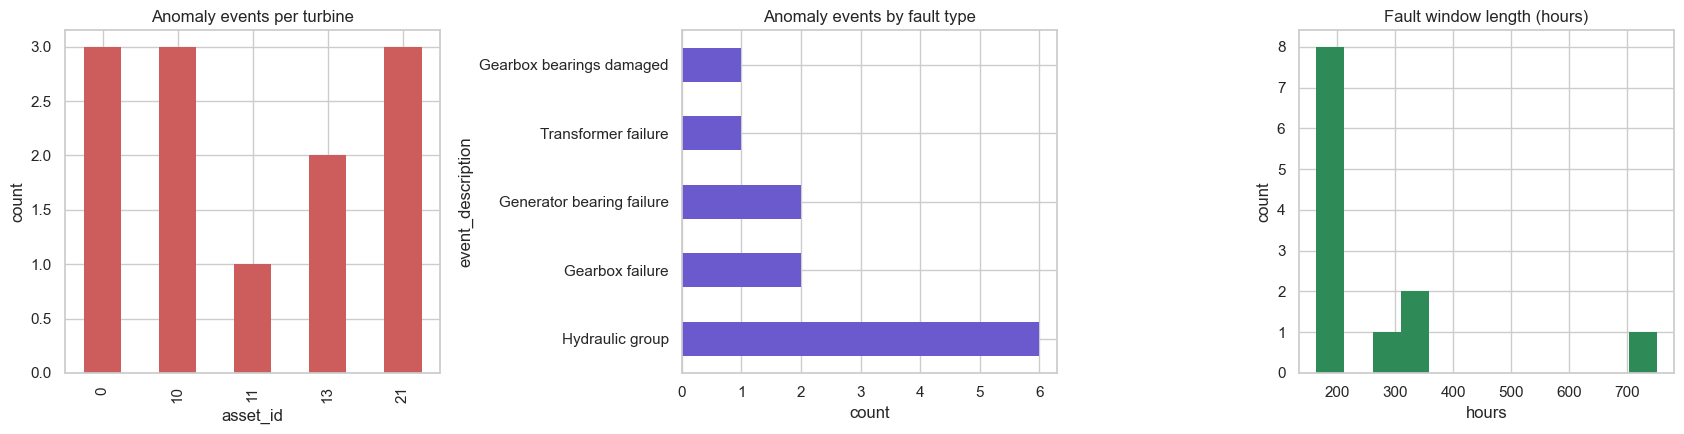

Fault window stats (hours):
count     12.0
mean     253.2
std      170.9
min      163.3
25%      167.6
50%      168.0
75%      292.8
max      751.2
Name: window_hours, dtype: float64

Per-event detail:
 asset         event_description  window_rows  window_hours
    10           Gearbox failure          980    163.333333
    21           Hydraulic group         1004    167.333333
    13           Hydraulic group         1004    167.333333
    10           Hydraulic group         1006    167.666667
    13           Hydraulic group         1007    167.833333
    21           Gearbox failure         1008    168.000000
     0           Hydraulic group         1008    168.000000
     0           Hydraulic group         1008    168.000000
    21  Gearbox bearings damaged         1672    278.666667
     0 Generator bearing failure         2011    335.166667
    11       Transformer failure         2013    335.500000
    10 Generator bearing failure         4507    751.166667


In [4]:
anomalies = events[events["event_label"] == "anomaly"].copy()

# Window length (in rows) for each anomaly, from the id boundaries
anomalies["window_rows"] = anomalies["event_end_id"] - anomalies["event_start_id"]
anomalies["window_hours"] = anomalies["window_rows"] * 10 / 60  # 10-min sampling

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) anomalies per turbine
anomalies["asset"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="indianred", edgecolor="none")
axes[0].set_title("Anomaly events per turbine")
axes[0].set_xlabel("asset_id"); axes[0].set_ylabel("count")

# (b) anomalies per fault type
anomalies["event_description"].value_counts().plot(
    kind="barh", ax=axes[1], color="slateblue", edgecolor="none")
axes[1].set_title("Anomaly events by fault type")
axes[1].set_xlabel("count")

# (c) fault window length distribution
axes[2].hist(anomalies["window_hours"], bins=12, color="seagreen", edgecolor="none")
axes[2].set_title("Fault window length (hours)")
axes[2].set_xlabel("hours"); axes[2].set_ylabel("count")

plt.tight_layout()
plt.savefig("../reports/figures/02_event_structure.png", dpi=120, bbox_inches="tight")
plt.show()

print("Fault window stats (hours):")
print(anomalies["window_hours"].describe().round(1))
print("\nPer-event detail:")
print(anomalies[["asset","event_description","window_rows","window_hours"]]
      .sort_values("window_hours").to_string(index=False))

### Event-structure findings

- **Turbine spread:** anomalies cover all 5 turbines (3/3/1/2/3 for assets
  0/10/11/13/21). Asset 11 has only the single transformer event. Spread is
  adequate for **leave-turbines-out** validation.
- **Fault types:** Hydraulic (6) ≫ gearbox-related (3) > generator bearing (2) >
  transformer (1). Confirms a **binary** target only — per-component modelling is
  impossible (1 transformer example).
- **Window length:** most fault windows are a near-uniform **~1004–1008 rows (~7
  days)**, with three longer exceptions (gearbox-bearings ~11 d; generator-bearing
  ~14 d and ~31 d). The uniformity indicates the pre-fault window is largely a
  **fixed labeling horizon**, not organically detected onset.
- **Implication / limitation:** the labeled window edges are somewhat arbitrary;
  true degradation may begin earlier. Target = "within the labeled pre-fault
  window"; we state the horizon assumption explicitly.

## 3. Pre-fault sensor behaviour — is there a signal?

The core question of the whole project: do sensors drift measurably *before* the
fault window? We take anomaly runs, mark the labeled window
(`event_start_id`→`event_end_id`), and plot condition-related temperatures over
time. If temps rise ahead of the window, a predictive signal exists and the
modelling is justified. We compare against a normal run as a baseline.

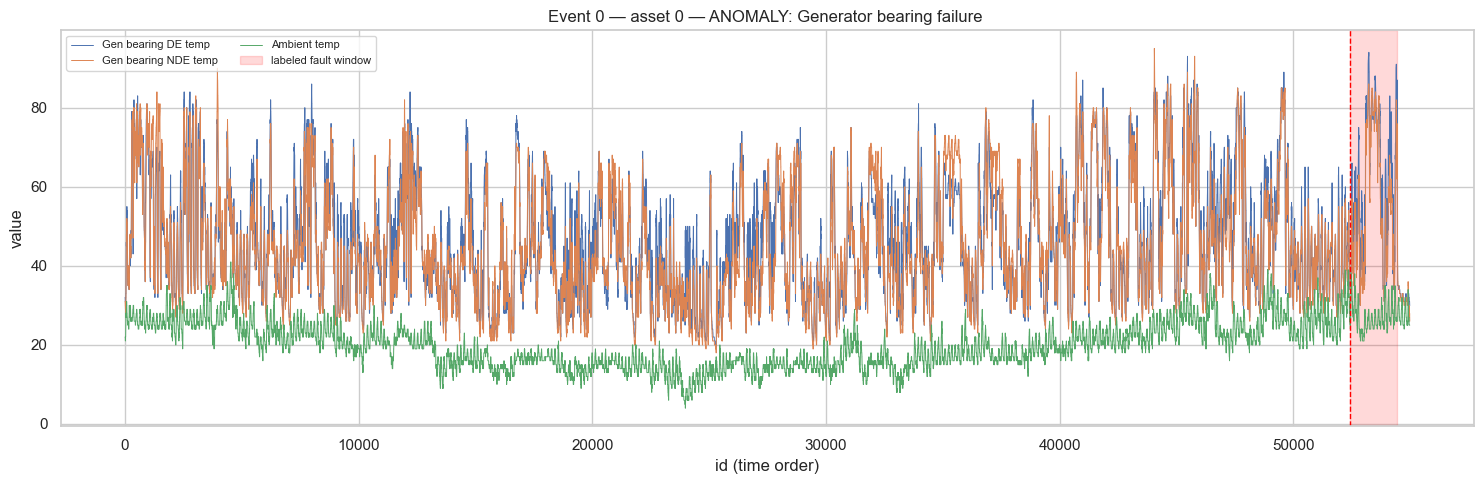

In [5]:
def plot_event_timeline(event_id, sensors, title_extra=""):
    """Plot sensors over time for one dataset, shading the fault window if anomaly."""
    d = load_dataset(event_id)
    row = events.loc[events["event_id"] == event_id].iloc[0]
    is_anom = row["event_label"] == "anomaly"

    fig, ax = plt.subplots(figsize=(15, 5))
    for col, label in sensors.items():
        ax.plot(d["id"], d[col], label=label, linewidth=0.7)

    if is_anom:
        ax.axvspan(row["event_start_id"], row["event_end_id"],
                   color="red", alpha=0.15, label="labeled fault window")
        ax.axvline(row["event_start_id"], color="red", linestyle="--", linewidth=1)

    kind = row["event_label"].upper()
    desc = row["event_description"] if is_anom else "normal run"
    ax.set_title(f"Event {event_id} — asset {row['asset']} — {kind}: {desc} {title_extra}")
    ax.set_xlabel("id (time order)"); ax.set_ylabel("value")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    plt.tight_layout()
    return fig

# Generator bearing failure (asset 0, event 0) — Expect a bearing-temp climb
gen_sensors = {
    "sensor_13_avg": "Gen bearing DE temp",
    "sensor_14_avg": "Gen bearing NDE temp",
    "sensor_0_avg":  "Ambient temp",
}
fig = plot_event_timeline(0, gen_sensors)
plt.savefig("../reports/figures/02_prefault_genbearing.png", dpi=120, bbox_inches="tight")
plt.show()

### Pre-fault signal findings

- **A real but subtle signal exists.** Approaching and inside the labeled fault
  window, generator-bearing temps (DE & NDE) reach their most sustained highs of
  the run (~85–95 °C), while **ambient temp stays flat** — so the rise is not
  weather-driven. The bearings run hotter *relative to ambient* near the fault.
- **It is NOT a clean threshold.** Bearing temps spike to 80–85 °C repeatedly
  throughout normal operation too (turbine runs hot under load, cools when idle).
  A single absolute threshold would false-alarm constantly on earlier spikes.
- **Implication for modelling:** the signal lives in *sustained elevation,
  frequency, and rate-of-change* near the fault — not raw instantaneous values.
  This **justifies engineered features** (rolling mean/std, rate-of-change,
  bearing-minus-ambient deltas) in NB04 rather than feeding raw sensors.
- **Honest limitation:** the signal is noisy and buried, as expected in real
  SCADA predictive maintenance — not a dramatic visual ramp.

## 4. Does the pre-fault signal hold across events?

The timeline for event 0 suggested bearing temps run hotter (relative to ambient)
near the fault. But that's one event read by eye. Here we quantify it across
**all** anomaly events: for each, compare the bearing-minus-ambient temperature
delta *inside* the labeled fault window vs *outside* it. If the delta is
systematically higher inside across events, the signal is real, not cherry-picked

In [7]:
temp_sensors = {
    "sensor_13_avg": "Gen bearing DE",
    "sensor_14_avg": "Gen bearing NDE",
    "sensor_11_avg": "Gearbox bearing HS",
    "sensor_12_avg": "Gearbox oil",
}

rows = []
for _, ev in events[events["event_label"] == "anomaly"].iterrows():
    d = load_dataset(ev["event_id"])
    # Use rows where the turbine is actually producing (power > 0), NOT status filter,
    # so we don't accidentally delete the whole fault window (which is mostly status 4).
    d = d[d["power_30_avg"] > 0.05].copy()
    if len(d) == 0:
        continue

    inside = (d["id"] >= ev["event_start_id"]) & (d["id"] <= ev["event_end_id"])
    if inside.sum() == 0:
        continue
    amb = d["sensor_0_avg"]

    for col, label in temp_sensors.items():
        delta = d[col] - amb
        rows.append({
            "event_id": ev["event_id"],
            "asset": ev["asset"],
            "fault": ev["event_description"],
            "sensor": label,
            "delta_inside": delta[inside].mean(),
            "delta_outside": delta[~inside].mean(),
            "n_inside": int(inside.sum()),
        })

comp = pd.DataFrame(rows)
comp["diff"] = comp["delta_inside"] - comp["delta_outside"]

print("Rows available inside fault window (should be non-zero now):")
print(comp.groupby("sensor")["n_inside"].describe()[["min","mean","max"]].round(0))

print("\nMean (inside - outside) delta by sensor across anomaly events:")
print(comp.groupby("sensor")["diff"].agg(
    ["mean", "median", lambda s: f"{(s>0).sum()}/{s.notna().sum()} higher inside"]).round(2))

print("\nPer-event detail (Gen bearing DE):")
print(comp[comp["sensor"] == "Gen bearing DE"]
      [["asset","fault","delta_inside","delta_outside","diff"]]
      .round(1).to_string(index=False))

Rows available inside fault window (should be non-zero now):
                      min   mean     max
sensor                                  
Gearbox bearing HS  455.0  930.0  1921.0
Gearbox oil         455.0  930.0  1921.0
Gen bearing DE      455.0  930.0  1921.0
Gen bearing NDE     455.0  930.0  1921.0

Mean (inside - outside) delta by sensor across anomaly events:
                    mean  median          <lambda_0>
sensor                                              
Gearbox bearing HS -2.63   -3.16  2/12 higher inside
Gearbox oil        -2.88   -3.47  2/12 higher inside
Gen bearing DE     -0.35   -1.13  5/12 higher inside
Gen bearing NDE    -1.22   -2.67  4/12 higher inside

Per-event detail (Gen bearing DE):
 asset                     fault  delta_inside  delta_outside  diff
    11       Transformer failure          26.4           32.5  -6.1
    21           Hydraulic group          33.8           29.7   4.1
    21           Gearbox failure          27.6           29.3  -1.7
   

### Cross-event signal findings — the honest result

Quantifying bearing-minus-ambient delta (inside vs outside the fault window,
using `power > 0` to isolate running rows) across all 12 anomaly events:

- **The signal is NOT universal.** Averaged over events, the inside−outside delta
  is ~0 (Gen bearing DE: mean −0.35, only 5/12 events higher inside). Bearing
  temps do **not** systematically rise before *every* fault.
- **The signal IS fault-specific.** Where the failing component matches the sensor,
  the delta is strongly positive — e.g. asset 0's *generator bearing failure*
  shows +9.7 °C bearing-above-ambient inside the window. But asset 0's *hydraulic*
  fault shows −8.8 °C: bearing temp is irrelevant to a hydraulic failure.
- **Discovery — status/​fault entanglement:** an earlier version filtered to
  `status_type_id == 0` and returned almost all NaNs, because fault windows are
  overwhelmingly `status_type_id == 4`. So status-4 concentration is entangled with
  the fault window → **`status_type_id` is a leakage risk** and must be excluded
  from (or carefully handled in) modelling, not used as a feature.

**Implications for modelling:**
1. No single sensor threshold works. Different faults live in different sensors →
   favours a multivariate model + anomaly detection over hand-picked rules.
2. Per-fault-type prediction is data-starved (1 transformer, 2 gen-bearing) →
   target stays **binary** (pre-fault window vs normal), stated as a limitation.
3. **Exclude `status_type_id`** (and anything derived from it) from features to
   avoid target leakage.